# 05 — VGGT full: optional BA → synthetic views → adaptive 3DGS

This single GPU notebook takes one annotated eight-view car scene through the complete selected method:

1. verify and visualize the eight real inputs and BiRefNet masks;
2. run VGGT once and visualize cameras, depth-based 3D points, and confidence;
3. construct a frozen Gaussian-surfel teacher from foreground VGGT geometry;
4. render ten dense pseudo-views between each adjacent pair, with continuous confidence and binary validity;
5. diagnose pseudo-pixel reliability by reconstructing each real view without its own source points;
6. train adaptive 3DGS using **real + confidence-weighted synthetic supervision only**;
7. visualize real fits, pseudo-view fits, training curves, and a rotational MP4.

The public VGGT model does not contain the paper's unreleased learned RGB-NVS head. Here “pseudo-view” means a dense VGGT-geometry teacher render. VGGT's official implementation notes that unprojecting predicted depth with predicted cameras usually gives more accurate points than the direct point-map branch, so that is the default.


In [11]:
%pip -q install scipy trimesh pandas pillow matplotlib huggingface_hub einops safetensors opencv-python imageio imageio-ffmpeg pycolmap hydra-core omegaconf onnxruntime requests "gsplat==1.3.0"
!test -d /content/vggt/.git || git clone -q https://github.com/facebookresearch/vggt.git /content/vggt
%pip -q install --no-deps -e /content/vggt


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 750.0/750.0 kB 11.7 MB/s eta 0:00:00 0:00:01
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for vggt (pyproject.toml) ... done


In [12]:
import gc, shutil, subprocess, sys, time
from pathlib import Path
import imageio.v2 as imageio
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image
from IPython.display import Video, display
from google.colab import drive

if not torch.cuda.is_available():
    raise RuntimeError("Connect a Colab GPU runtime before running this notebook.")
print("GPU:", torch.cuda.get_device_name(0))
drive.mount("/content/drive", force_remount=False)

CODE_ROOT = Path("/content/Project_Thesis_code")
REPOSITORY = "ht" + "tps:" + chr(47)*2 + "github.com" + chr(47) + "katlit" + chr(47) + "Project_Thesis.git"
BRANCH = "codex/hq200-example-notebook"
if CODE_ROOT.exists() and not (CODE_ROOT / ".git").is_dir(): shutil.rmtree(CODE_ROOT)
command = (["git", "clone", "--depth", "1", "--branch", BRANCH, REPOSITORY, str(CODE_ROOT)]
           if not CODE_ROOT.exists() else ["git", "-C", str(CODE_ROOT), "pull", "--ff-only", "origin", BRANCH])
subprocess.run(command, check=True)
sys.path[:0] = [str(CODE_ROOT / "code"), "/content/vggt"]


GPU: NVIDIA A100-SXM4-40GB
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
from src.gaussian_full import initialize_full_gaussians, load_checkpoint, render_full, train_adaptive
from src.vggt_geometry import confidence_error_table, confidence_to_unit_interval, interpolate_closed_orbit, multiview_depth_support
from src.vggt_teacher import build_teacher_gaussians, coverage_summary, render_teacher
from src.vggt_bundle_adjustment import run_vggt_bundle_adjustment
from vggt.models.vggt import VGGT
from vggt.utils.geometry import unproject_depth_map_to_point_map
from vggt.utils.load_fn import load_and_preprocess_images
from vggt.utils.pose_enc import pose_encoding_to_extri_intri

PROJECT_ROOT = Path("/content/drive/MyDrive/ITU/3D/Thesis")
METHOD_MANIFEST = PROJECT_ROOT / "data_processed/method_inputs/manifest.csv"
EXPERIMENT_ROOT = PROJECT_ROOT / "experiments"

# ---------- scene ----------
DATASET = "3DRealCar"              # or IndustrialInventory
SCENE = None                        # None chooses first available scene
REFLECTION_HANDLED = False                   # future reflection-handled input/output variant

# ---------- VGGT geometry knobs ----------
VGGT_MODEL = "facebook/VGGT-1B"
USE_DEPTH_UNPROJECTION = True       # recommended; False uses direct world_points
CONFIDENCE_PERCENTILES = (5.0, 95.0)
POINT_CONFIDENCE_MIN = 0.05
COMPUTE_MULTIVIEW_SUPPORT = True
MIN_VIEW_SUPPORT = 1              # 1 preserves current behavior; inspect 2 and 3 in the sweep
DEPTH_RELATIVE_TOLERANCE = 0.05
DEPTH_ABSOLUTE_TOLERANCE = 0.01
TUNING_CONFIDENCE_THRESHOLDS = (0.00, 0.05, 0.10, 0.20, 0.40)
TUNING_MIN_VIEW_SUPPORT = (1, 2, 3)

# ---------- optional VGGT point-track bundle adjustment ----------
USE_BUNDLE_ADJUSTMENT = False
BA_ALLOW_FALLBACK = True
BA_MAX_REPROJECTION_ERROR = 8.0
BA_VISIBILITY_THRESHOLD = 0.20
BA_MAX_QUERY_POINTS = 4096
BA_QUERY_FRAME_COUNT = 8
BA_FINE_TRACKING = True
BA_SHARED_CAMERA = False
BA_REFINE_FOCAL_LENGTH = True
BA_REFINE_PRINCIPAL_POINT = False

# ---------- dense pseudo-view teacher knobs ----------
VIEWS_BETWEEN = 10                  # 10 => about 4.09 degrees for a 45-degree interval
TEACHER_MAX_POINTS = 150_000
TEACHER_SCALE_DIVISOR = 350.0
TEACHER_SCALE_MULTIPLIER = 2.5      # increase if pseudo-views have small holes
TEACHER_OPACITY = 0.95
PSEUDO_ALPHA_MIN = 0.55             # decrease for more coverage, less certainty
PSEUDO_CONFIDENCE_MIN = 0.10        # decrease for more coverage, less certainty

# ---------- adaptive 3DGS knobs ----------
STEPS = 30_000
INITIAL_GAUSSIANS = 50_000
SH_DEGREE = 3
SYNTHETIC_PROBABILITY = 0.25
SYNTHETIC_WEIGHT = 0.25
CHECKPOINT_EVERY = 5_000
RESUME = True

manifest = pd.read_csv(METHOD_MANIFEST)
available = manifest.query("method == 'vggt' and split == 'train' and dataset == @DATASET")
SCENE = SCENE or sorted(available.scene.unique())[0]
scene = available[available.scene.eq(SCENE)].sort_values(["view_order", "source"]).copy()
assert len(scene) == 8 and pd.to_numeric(scene.view_order).astype(int).tolist() == list(range(8))
dataset_name = {"3DRealCar": "3DRealCar", "IndustrialInventory": "Industrial"}[DATASET]
DATASET_VARIANT = dataset_name + ("_ref" if REFLECTION_HANDLED else "")
geometry_method = "VGGT_BA" if USE_BUNDLE_ADJUSTMENT else "VGGT"
synthetic_method = "VGGT_NVS_BA" if USE_BUNDLE_ADJUSTMENT else "VGGT_NVS"
THREEDGS_EXPERIMENT = geometry_method + ("_full_ref" if REFLECTION_HANDLED else "_full")
GEOMETRY_ROOT = EXPERIMENT_ROOT / "Geometry" / geometry_method / DATASET_VARIANT / SCENE
SYNTHETIC_ROOT = EXPERIMENT_ROOT / "SyntheticViews" / synthetic_method / DATASET_VARIANT / SCENE
SYNTHETIC_EVALUATION_ROOT = SYNTHETIC_ROOT / "evaluation"
MESH_EVALUATION_ROOT = GEOMETRY_ROOT / "mesh_evaluation"
RUN_ROOT = EXPERIMENT_ROOT / "3DGS" / THREEDGS_EXPERIMENT / DATASET_VARIANT / SCENE
for directory in [GEOMETRY_ROOT, SYNTHETIC_EVALUATION_ROOT, MESH_EVALUATION_ROOT, RUN_ROOT]:
    directory.mkdir(parents=True, exist_ok=True)
print("Selected:", DATASET_VARIANT, SCENE)
print("Geometry:", GEOMETRY_ROOT)
print("Synthetic views:", SYNTHETIC_ROOT)
print("3DGS:", RUN_ROOT)


Selected: 3DRealCar 2024_09_11_12_52_22
Geometry: /content/drive/MyDrive/ITU/3D/Thesis/experiments/Geometry/VGGT/3DRealCar/2024_09_11_12_52_22
Synthetic views: /content/drive/MyDrive/ITU/3D/Thesis/experiments/SyntheticViews/VGGT_NVS/3DRealCar/2024_09_11_12_52_22
3DGS: /content/drive/MyDrive/ITU/3D/Thesis/experiments/3DGS/VGGT_full/3DRealCar/2024_09_11_12_52_22


## 1. Verify inputs and masks


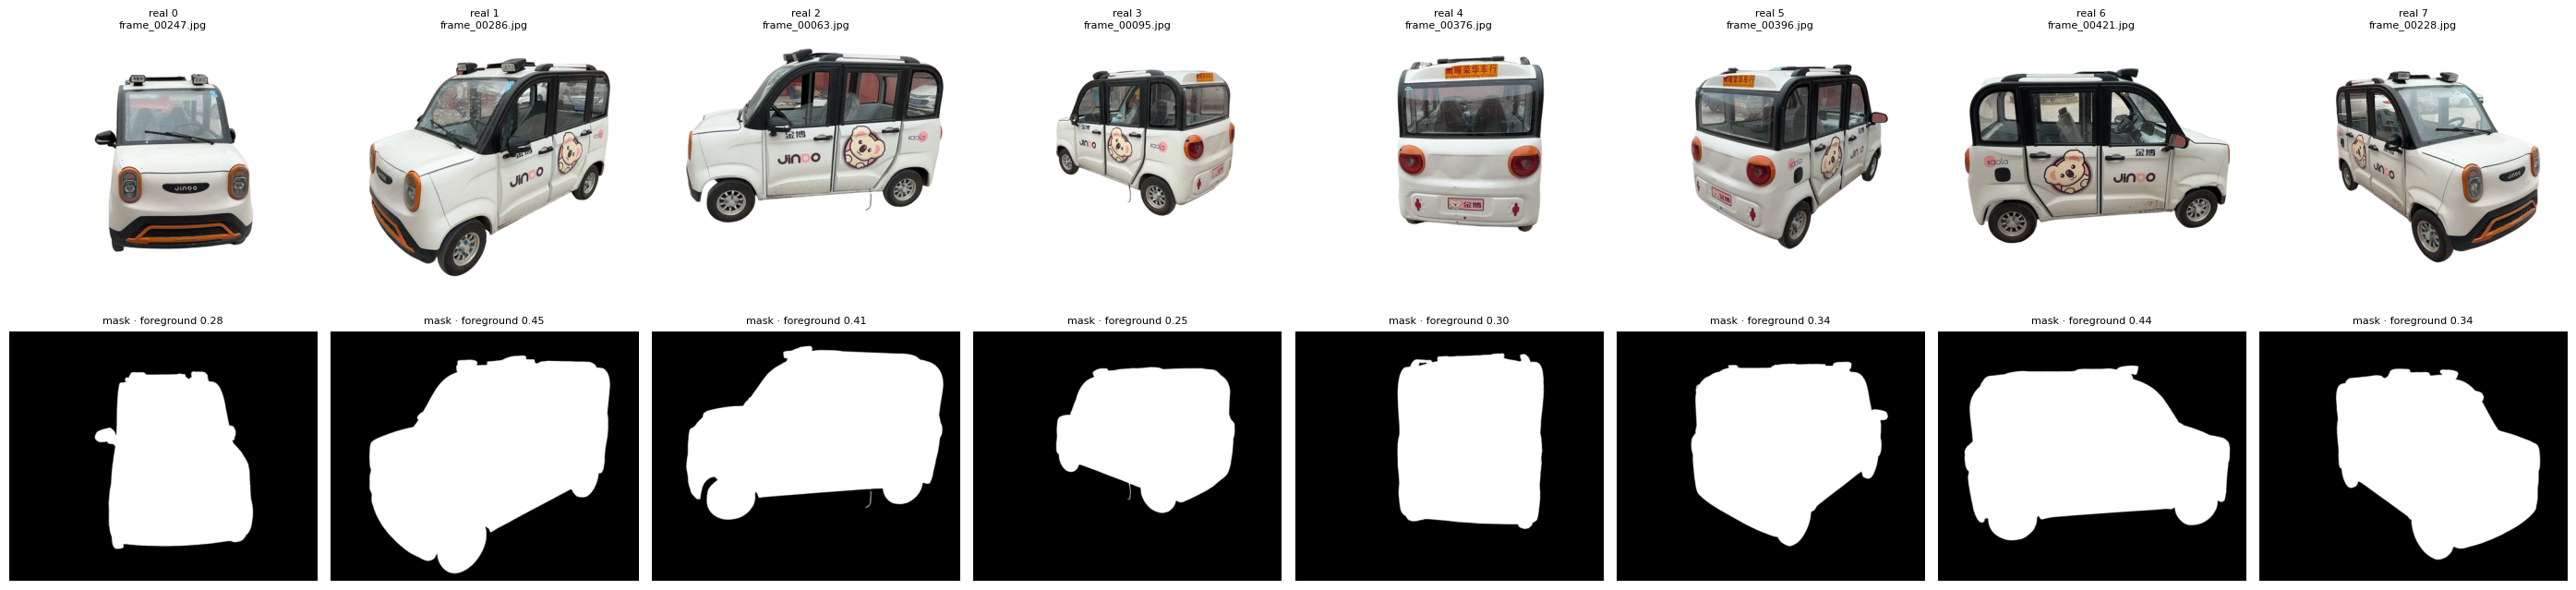

In [14]:
fig, axes = plt.subplots(2, 8, figsize=(28, 7), squeeze=False)
for index, row in enumerate(scene.itertuples(index=False)):
    rgb = np.asarray(Image.open(row.method_image).convert("RGB"))
    mask = np.asarray(Image.open(row.method_mask).convert("L"))
    axes[0, index].imshow(rgb); axes[1, index].imshow(mask, cmap="gray", vmin=0, vmax=255)
    axes[0, index].set_title(f"real {index}\n{Path(row.source).name}", fontsize=8)
    axes[1, index].set_title(f"mask · foreground {np.mean(mask >= 128):.2f}", fontsize=8)
    axes[0, index].axis("off"); axes[1, index].axis("off")
axes[0, 0].set_ylabel("VGGT RGB"); axes[1, 0].set_ylabel("BiRefNet mask")
plt.tight_layout(); plt.show()


## 2. VGGT cameras, depth geometry, and confidence


In [15]:
image_paths = scene.method_image.tolist()
images = load_and_preprocess_images(image_paths).to("cuda")
model = VGGT.from_pretrained(VGGT_MODEL).to("cuda").eval()
dtype = torch.bfloat16 if torch.cuda.get_device_capability()[0] >= 8 else torch.float16
with torch.inference_mode(), torch.cuda.amp.autocast(dtype=dtype):
    prediction_torch = model(images)
    extrinsic_t, intrinsic_t = pose_encoding_to_extri_intri(prediction_torch["pose_enc"], images.shape[-2:])
prediction = {key: value.detach().float().cpu().numpy().squeeze(0)
              for key, value in prediction_torch.items() if isinstance(value, torch.Tensor)}
extrinsics = extrinsic_t.detach().float().cpu().numpy().squeeze(0)
intrinsics = intrinsic_t.detach().float().cpu().numpy().squeeze(0)
colors = prediction["images"].transpose(0, 2, 3, 1)
height, width = colors.shape[1:3]
masks = np.stack([np.asarray(Image.open(path).convert("L").resize((width, height), Image.Resampling.NEAREST)) >= 128
                  for path in scene.method_mask])
raw_confidence = prediction["depth_conf"] if USE_DEPTH_UNPROJECTION else prediction["world_points_conf"]
confidence = np.stack([confidence_to_unit_interval(
    raw_confidence[index], masks[index], *CONFIDENCE_PERCENTILES
) for index in range(8)])
points_by_view = (unproject_depth_map_to_point_map(
    prediction["depth"], extrinsics, intrinsics
) if USE_DEPTH_UNPROJECTION else prediction["world_points"])
feedforward_extrinsics, feedforward_intrinsics = extrinsics.copy(), intrinsics.copy()
ba_diagnostics = {"enabled": USE_BUNDLE_ADJUSTMENT, "used": False}
if USE_BUNDLE_ADJUSTMENT:
    try:
        extrinsics, intrinsics, reconstruction, ba_report = run_vggt_bundle_adjustment(
            images, raw_confidence, points_by_view, colors, masks, extrinsics, intrinsics,
            max_reprojection_error=BA_MAX_REPROJECTION_ERROR,
            visibility_threshold=BA_VISIBILITY_THRESHOLD,
            max_query_points=BA_MAX_QUERY_POINTS, query_frame_count=BA_QUERY_FRAME_COUNT,
            fine_tracking=BA_FINE_TRACKING, shared_camera=BA_SHARED_CAMERA,
            refine_focal_length=BA_REFINE_FOCAL_LENGTH,
            refine_principal_point=BA_REFINE_PRINCIPAL_POINT,
        )
        points_by_view = unproject_depth_map_to_point_map(prediction["depth"], extrinsics, intrinsics)
        sparse_root = GEOMETRY_ROOT / "colmap" / "sparse"
        sparse_root.mkdir(parents=True, exist_ok=True)
        reconstruction.write(str(sparse_root))
        ba_diagnostics = {"enabled": True, "used": True, **ba_report}
    except Exception as error:
        ba_diagnostics = {"enabled": True, "used": False, "error": repr(error)}
        if not BA_ALLOW_FALLBACK:
            raise
        extrinsics, intrinsics = feedforward_extrinsics, feedforward_intrinsics
        points_by_view = (unproject_depth_map_to_point_map(prediction["depth"], extrinsics, intrinsics)
                          if USE_DEPTH_UNPROJECTION else prediction["world_points"])
        print("WARNING: BA failed; continuing with feed-forward VGGT:", error)
pd.DataFrame([ba_diagnostics]).to_csv(GEOMETRY_ROOT / "bundle_adjustment.csv", index=False)
display(pd.DataFrame([ba_diagnostics]))
if ba_diagnostics["used"]:
    def camera_centers(values):
        homogeneous = np.concatenate([values, np.tile([[[0, 0, 0, 1]]], (len(values), 1, 1))], axis=1)
        return np.linalg.inv(homogeneous)[:, :3, 3]
    before_centers = camera_centers(feedforward_extrinsics)
    after_centers = camera_centers(extrinsics)
    figure = plt.figure(figsize=(8, 7))
    axis = figure.add_subplot(111, projection="3d")
    for centers_to_plot, label, color in [(before_centers, "VGGT", "tab:gray"), (after_centers, "VGGT + BA", "tab:blue")]:
        closed = np.vstack([centers_to_plot, centers_to_plot[0]])
        axis.plot(*closed.T, "o-", label=label, color=color)
    axis.set_title("Camera orbit before and after bundle adjustment")
    axis.legend()
    axis.set_box_aspect(np.ptp(np.vstack([before_centers, after_centers]), axis=0).clip(min=1e-6))
    plt.show()
support = (multiview_depth_support(
    points_by_view, prediction["depth"], extrinsics, intrinsics, masks,
    relative_tolerance=DEPTH_RELATIVE_TOLERANCE, absolute_tolerance=DEPTH_ABSOLUTE_TOLERANCE,
) if COMPUTE_MULTIVIEW_SUPPORT else masks.astype(np.uint8))
geometry_keep = (masks & np.isfinite(points_by_view).all(axis=-1) &
                 (confidence >= POINT_CONFIDENCE_MIN) & (support >= MIN_VIEW_SUPPORT))
np.savez_compressed(GEOMETRY_ROOT / "vggt_geometry.npz", points=points_by_view,
                   raw_confidence=raw_confidence, confidence=confidence,
                   extrinsics=extrinsics, intrinsics=intrinsics, masks=masks, support=support)
print("VGGT size:", width, "x", height, "| geometry:", "depth-unprojected" if USE_DEPTH_UNPROJECTION else "direct point map")
del model, prediction_torch, images
gc.collect(); torch.cuda.empty_cache()


/tmp/ipykernel_9150/4235004998.py:5: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.inference_mode(), torch.cuda.amp.autocast(dtype=dtype):
/content/vggt/vggt/models/vggt.py:65: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):


VGGT size: 518 x 420 | geometry: depth-unprojected


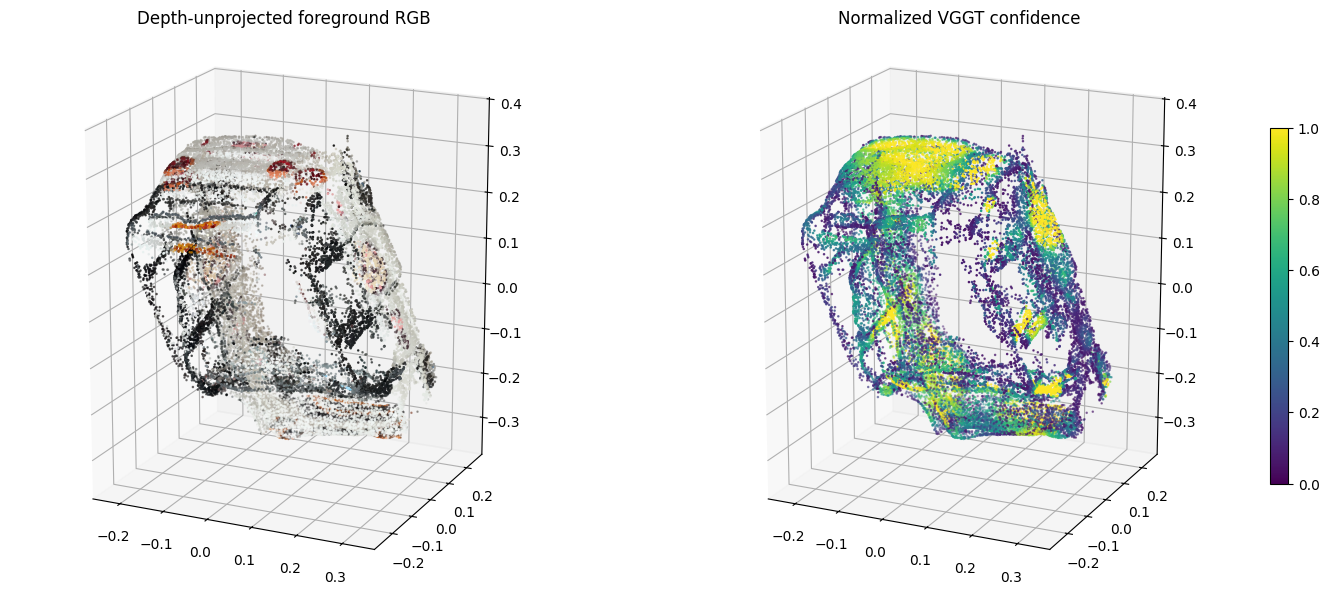

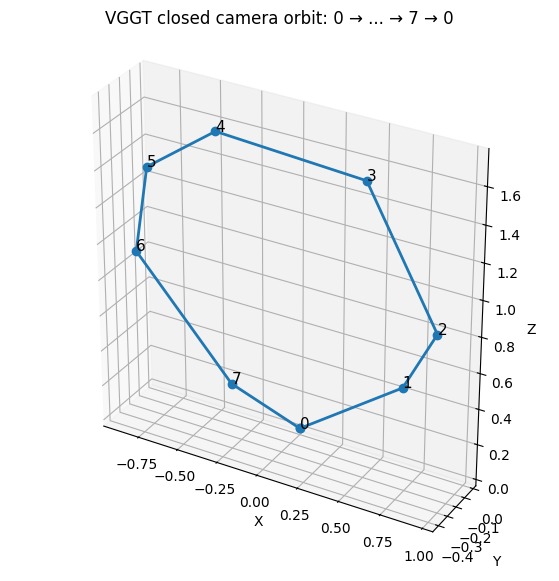

In [16]:
tuning_rows = []
for threshold in TUNING_CONFIDENCE_THRESHOLDS:
    for minimum_support in TUNING_MIN_VIEW_SUPPORT:
        selected = masks & np.isfinite(points_by_view).all(axis=-1) & (confidence >= threshold) & (support >= minimum_support)
        tuning_rows.append({"confidence_min": threshold, "minimum_view_support": minimum_support,
                            "points": int(selected.sum()),
                            "retained_%_of_foreground": 100 * selected.sum() / max(masks.sum(), 1)})
display(pd.DataFrame(tuning_rows).round(2))
print("Active geometry:", int(geometry_keep.sum()), "points | confidence >=", POINT_CONFIDENCE_MIN,
      "| support >=", MIN_VIEW_SUPPORT)
keep = geometry_keep
points, point_colors, point_conf = points_by_view[keep], colors[keep], confidence[keep]
rng = np.random.default_rng(42)
if len(points) > 25_000:
    chosen = rng.choice(len(points), 25_000, replace=False)
    points, point_colors, point_conf = points[chosen], point_colors[chosen], point_conf[chosen]
centered = points - np.median(points, axis=0)
visible = np.linalg.norm(centered, axis=1) <= np.percentile(np.linalg.norm(centered, axis=1), 99)
centered, point_colors, point_conf = centered[visible], point_colors[visible], point_conf[visible]
fig = plt.figure(figsize=(15, 6)); ax1 = fig.add_subplot(121, projection="3d"); ax2 = fig.add_subplot(122, projection="3d")
ax1.scatter(*centered.T, c=np.clip(point_colors, 0, 1), s=.7)
plot = ax2.scatter(*centered.T, c=point_conf, cmap="viridis", vmin=0, vmax=1, s=.7)
for axis, title in [(ax1, "Depth-unprojected foreground RGB"), (ax2, "Normalized VGGT confidence")]:
    axis.set_title(title); axis.set_box_aspect(np.ptp(centered, axis=0).clip(min=1e-6)); axis.view_init(18, -65)
fig.colorbar(plot, ax=ax2, shrink=.65); plt.tight_layout(); plt.show()

camera_to_world = np.linalg.inv(
    np.concatenate(
        [
            extrinsics,
            np.tile(
                np.array(
                    [0, 0, 0, 1],
                    dtype=np.float32,
                ),
                (len(extrinsics), 1, 1),
            ),
        ],
        axis=1,
    )
)

centers = camera_to_world[:, :3, 3]

# Append camera 0 to close the displayed orbit.
closed_centers = np.vstack([
    centers,
    centers[0],
])

fig = plt.figure(figsize=(8, 7))
axis = fig.add_subplot(
    111,
    projection="3d",
)

axis.plot(
    closed_centers[:, 0],
    closed_centers[:, 1],
    closed_centers[:, 2],
    "o-",
    linewidth=2,
)

for index, center in enumerate(centers):
    axis.text(
        center[0],
        center[1],
        center[2],
        str(index),
        fontsize=11,
    )

axis.set_title(
    "VGGT closed camera orbit: 0 → ... → 7 → 0"
)

axis.set_xlabel("X")
axis.set_ylabel("Y")
axis.set_zlabel("Z")

axis.set_box_aspect(
    np.ptp(
        closed_centers,
        axis=0,
    ).clip(min=1e-6)
)

plt.show()

In [17]:
finite = np.isfinite(points_by_view).all(axis=-1)
confident = confidence >= POINT_CONFIDENCE_MIN
retained = geometry_keep

rows = []
for view_index in range(len(points_by_view)):
    foreground_count = int(masks[view_index].sum())
    retained_count = int(retained[view_index].sum())

    rows.append({
        "view": view_index,
        "image_pixels": int(masks[view_index].size),
        "foreground_pixels": foreground_count,
        "finite_foreground": int(
            (masks[view_index] & finite[view_index]).sum()
        ),
        "confident_foreground": retained_count,
        "retained_%_of_foreground": (
            100 * retained_count / max(foreground_count, 1)
        ),
        "confidence_median_foreground": float(
            np.median(confidence[view_index][masks[view_index]])
        ),
    })

point_diagnostics = pd.DataFrame(rows)

display(point_diagnostics.round(2))

print("All predicted points:", points_by_view.shape[0] * points_by_view.shape[1] * points_by_view.shape[2])
print("Foreground points:", int(masks.sum()))
print("Points retained for geometry:", int(retained.sum()))
print("Points displayed by current plot:", min(int(retained.sum()), 25_000))

,view,image_pixels,foreground_pixels,finite_foreground,confident_foreground,retained_%_of_foreground,confidence_median_foreground
0,0,217560,60913,60913,44375,72.85,0.41
1,1,217560,98739,98739,44534,45.10,0.03
2,2,217560,89720,89720,44700,49.82,0.05
3,3,217560,54221,54221,13946,25.72,0.00
4,4,217560,65766,65766,44613,67.84,0.43
5,5,217560,73053,73053,46994,64.33,0.17
6,6,217560,95469,95469,67477,70.68,0.29
7,7,217560,74860,74860,46830,62.56,0.11


All predicted points: 1740480
Foreground points: 612741
Points retained for geometry: 353469
Points displayed by current plot: 25000


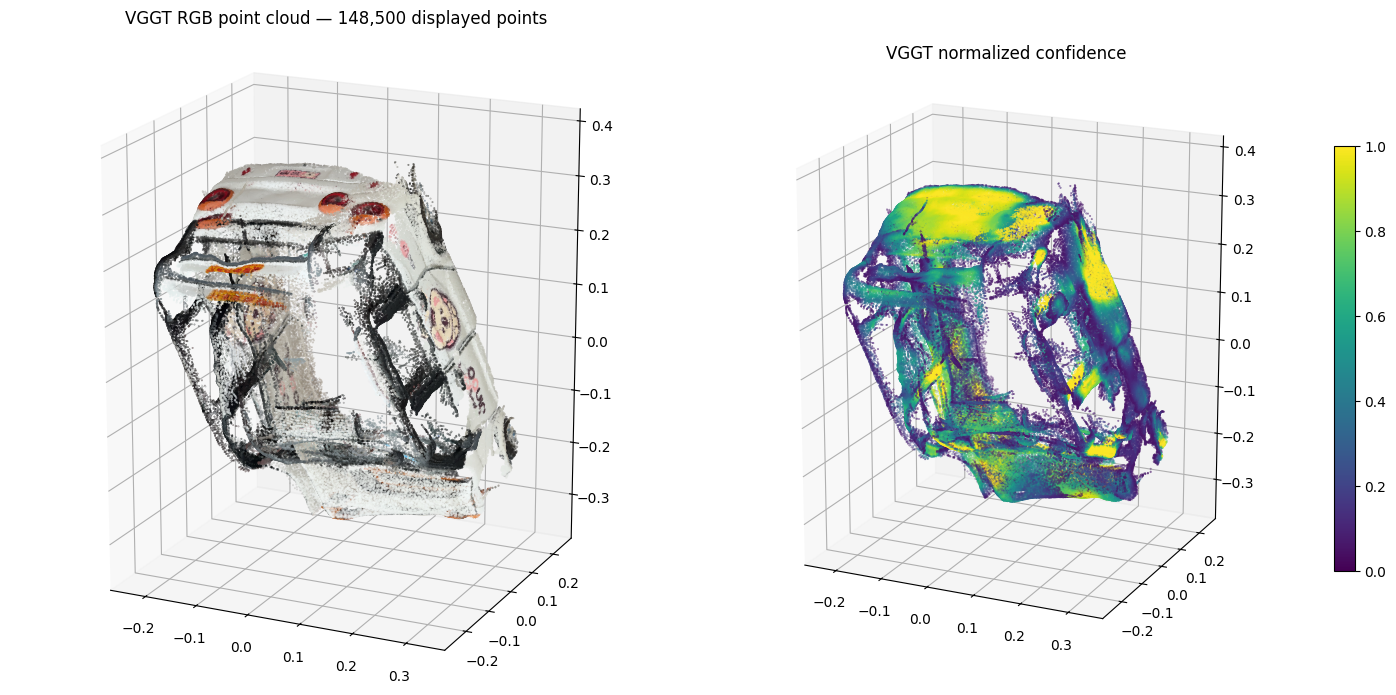

In [19]:
MAX_VIS_POINTS = 150_000

points = points_by_view[retained]
point_colors = colors[retained]
point_conf = confidence[retained]

rng = np.random.default_rng(42)

if len(points) > MAX_VIS_POINTS:
    chosen = rng.choice(
        len(points),
        MAX_VIS_POINTS,
        replace=False,
    )
    points = points[chosen]
    point_colors = point_colors[chosen]
    point_conf = point_conf[chosen]

center = np.median(points, axis=0)
centered = points - center

distance = np.linalg.norm(centered, axis=1)
visible = distance <= np.percentile(distance, 99)

centered = centered[visible]
point_colors = point_colors[visible]
point_conf = point_conf[visible]

fig = plt.figure(figsize=(15, 7))

ax1 = fig.add_subplot(121, projection="3d")
ax2 = fig.add_subplot(122, projection="3d")

ax1.scatter(
    centered[:, 0],
    centered[:, 1],
    centered[:, 2],
    c=np.clip(point_colors, 0, 1),
    s=0.15,
)

confidence_plot = ax2.scatter(
    centered[:, 0],
    centered[:, 1],
    centered[:, 2],
    c=point_conf,
    cmap="viridis",
    vmin=0,
    vmax=1,
    s=0.15,
)

extent = np.ptp(centered, axis=0).clip(min=1e-6)

for axis, title in [
    (ax1, f"VGGT RGB point cloud — {len(centered):,} displayed points"),
    (ax2, "VGGT normalized confidence"),
]:
    axis.set_title(title)
    axis.set_box_aspect(extent)
    axis.view_init(elev=18, azim=-65)

fig.colorbar(confidence_plot, ax=ax2, shrink=0.65)
plt.tight_layout()
plt.show()

### 2A. Reference-mesh evaluation (3DRealCar only)

The plot above intentionally shows at most 25,000 points, so apparent display sparsity is not a density measurement. The first table below reports how many foreground points survive each filter.

For 3DRealCar, this section uniformly samples the supplied scanner-derived triangle mesh, aligns VGGT geometry using a 7-DoF similarity transform (scale, rotation, and translation) followed by robust ICP, and reports accuracy, completeness, symmetric Chamfer-L1, and F-score. The scanner mesh is reference geometry rather than guaranteed metrology-grade ground truth. Metrics are invalid without alignment because VGGT scale and coordinates are arbitrary. IndustrialInventory has no corresponding reference mesh, so this section skips it.


,view,image_pixels,foreground_pixels,finite_foreground,retained_geometry,retained_%_of_foreground,median_foreground_confidence
0,0,217560,60913,60913,44375,72.85,0.41
1,1,217560,98739,98739,44534,45.10,0.03
2,2,217560,89720,89720,44700,49.82,0.05
3,3,217560,54221,54221,13946,25.72,0.00
4,4,217560,65766,65766,44613,67.84,0.43
5,5,217560,73053,73053,46994,64.33,0.17
6,6,217560,95469,95469,67477,70.68,0.29
7,7,217560,74860,74860,46830,62.56,0.11


Retained geometry: 353,469 points; earlier plot displayed at most 25,000.
Reference mesh: /content/drive/MyDrive/ITU/3D/Thesis/data/3DrealCarHQ200/2024_09_11_12_52_22/textured_output.obj
Reference vertices/faces: 194879 / 317250
Reference XYZ dimensions: [8.392  1.6188 8.3018] mesh units
Approximate XYZ dimensions (m): [8.392  1.6188 8.3018]
Spatial filter retained 351,701 points (99.5% radius percentile).


,predicted_points,reference_points,accuracy_mean_cm,accuracy_median_cm,completeness_mean_cm,completeness_median_cm,chamfer_l1_cm,precision@0.01,recall@0.01,fscore@0.01,precision@0.02,recall@0.02,fscore@0.02,precision@0.05,recall@0.05,fscore@0.05,scene,similarity_scale,reference_units_per_metre
0,100000,100000,49.7467,41.3674,50.8021,32.5041,50.2744,0.0037,0.0042,0.0039,0.0187,0.0208,0.0197,0.0634,0.0854,0.0728,2024_09_11_12_52_22,8.3053,1.0


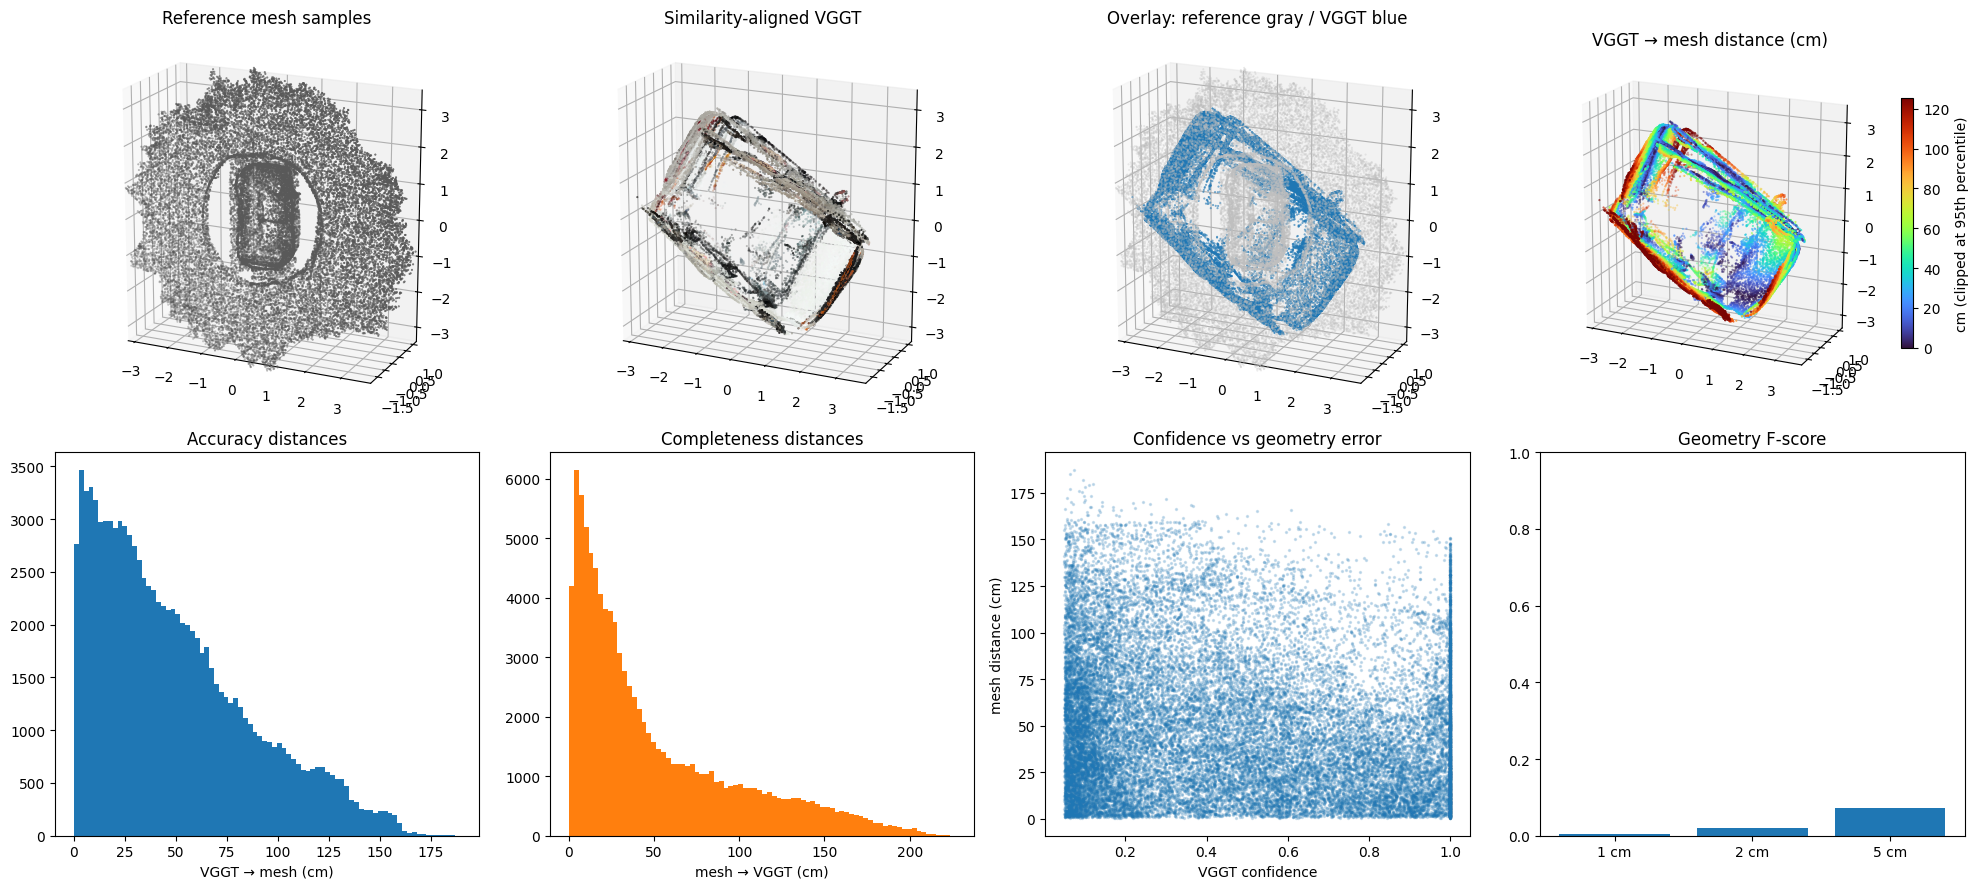

Saved mesh evaluation under: /content/drive/MyDrive/ITU/3D/Thesis/experiments/Geometry/VGGT/3DRealCar/2024_09_11_12_52_22/mesh_evaluation


In [20]:
import trimesh
from src.geometry_evaluation import align_similarity_icp, apply_similarity, geometry_metrics

# Evaluation knobs. HQ200 meshes are expected to use metres; verify the printed dimensions.
REFERENCE_SAMPLE_POINTS = 100_000
ALIGNMENT_MAX_POINTS = 12_000
EVALUATION_MAX_PREDICTED_POINTS = 100_000
EVALUATION_OUTLIER_PERCENTILE = 99.5
REFERENCE_UNITS_PER_METRE = 1.0
F_SCORE_THRESHOLDS_METRES = (0.01, 0.02, 0.05)

finite = np.isfinite(points_by_view).all(axis=-1)
confident = confidence >= POINT_CONFIDENCE_MIN
retained = geometry_keep
density_rows = []
for view_index in range(len(points_by_view)):
    foreground_count = int(masks[view_index].sum())
    retained_count = int(retained[view_index].sum())
    density_rows.append({
        "view": view_index,
        "image_pixels": int(masks[view_index].size),
        "foreground_pixels": foreground_count,
        "finite_foreground": int((masks[view_index] & finite[view_index]).sum()),
        "median_view_support": float(np.median(support[view_index][masks[view_index]])),
        "retained_geometry": retained_count,
        "retained_%_of_foreground": 100 * retained_count / max(foreground_count, 1),
        "median_foreground_confidence": float(np.median(confidence[view_index][masks[view_index]])),
    })
density_statistics = pd.DataFrame(density_rows)
display(density_statistics.round(2))
print(f"Retained geometry: {retained.sum():,} points; earlier plot displayed at most 25,000.")

if DATASET != "3DRealCar":
    print("Reference-mesh evaluation skipped: IndustrialInventory has no supplied HQ200 mesh.")
else:
    mesh_path = PROJECT_ROOT / "data_processed/reference_meshes/3DRealCar" / SCENE / "car_reference.obj"
    if not mesh_path.is_file():
        raise FileNotFoundError(
            f"Clean car reference missing: {mesh_path}\n"
            "Run 04_hq200_reference_mesh_cleanup.ipynb and approve this scene first. "
            "The raw textured_output.obj is deliberately not used because its background invalidates the metrics."
        )

    reference_mesh = trimesh.load_mesh(mesh_path, force="mesh", process=False)
    if reference_mesh.is_empty or len(reference_mesh.faces) == 0:
        raise ValueError(f"Reference mesh is empty or has no faces: {mesh_path}")
    reference_points, _ = trimesh.sample.sample_surface(
        reference_mesh, REFERENCE_SAMPLE_POINTS, seed=42
    )
    reference_extent = np.ptp(reference_points, axis=0)
    print("Reference mesh:", mesh_path)
    print("Reference vertices/faces:", len(reference_mesh.vertices), "/", len(reference_mesh.faces))
    print("Reference XYZ dimensions:", np.round(reference_extent, 4), "mesh units")
    print("Approximate XYZ dimensions (m):", np.round(reference_extent / REFERENCE_UNITS_PER_METRE, 4))

    predicted_points = points_by_view[retained]
    predicted_colors = colors[retained]
    predicted_confidence = confidence[retained]
    predicted_center = np.median(predicted_points, axis=0)
    radius = np.linalg.norm(predicted_points - predicted_center, axis=1)
    spatial_keep = radius <= np.percentile(radius, EVALUATION_OUTLIER_PERCENTILE)
    predicted_points = predicted_points[spatial_keep]
    predicted_colors = predicted_colors[spatial_keep]
    predicted_confidence = predicted_confidence[spatial_keep]
    print(f"Spatial filter retained {len(predicted_points):,} points "
          f"({EVALUATION_OUTLIER_PERCENTILE}% radius percentile).")

    transform = align_similarity_icp(
        predicted_points, reference_points,
        max_points=ALIGNMENT_MAX_POINTS, iterations=30, trim_fraction=0.80, seed=42,
    )
    predicted_aligned = apply_similarity(predicted_points, transform)
    rng = np.random.default_rng(42)
    if len(predicted_aligned) > EVALUATION_MAX_PREDICTED_POINTS:
        selected = rng.choice(len(predicted_aligned), EVALUATION_MAX_PREDICTED_POINTS, replace=False)
        predicted_aligned = predicted_aligned[selected]
        predicted_colors = predicted_colors[selected]
        predicted_confidence = predicted_confidence[selected]

    thresholds = tuple(value * REFERENCE_UNITS_PER_METRE for value in F_SCORE_THRESHOLDS_METRES)
    metric_values, pred_to_ref, ref_to_pred = geometry_metrics(
        predicted_aligned, reference_points, thresholds
    )
    metric_values.update({
        "scene": SCENE, "mesh": str(mesh_path), "similarity_scale": transform["scale"],
        "reference_units_per_metre": REFERENCE_UNITS_PER_METRE,
    })
    geometry_summary = pd.DataFrame([metric_values])
    geometry_summary.to_csv(MESH_EVALUATION_ROOT / "metrics.csv", index=False)
    np.savez_compressed(
        MESH_EVALUATION_ROOT / "alignment.npz",
        scale=transform["scale"], rotation=transform["rotation"],
        translation=transform["translation"], predicted_aligned=predicted_aligned,
        reference_points=reference_points, pred_to_ref=pred_to_ref, ref_to_pred=ref_to_pred,
    )

    distance_columns = ["accuracy_mean", "accuracy_median", "completeness_mean",
                        "completeness_median", "chamfer_l1"]
    readable = geometry_summary.copy()
    readable[distance_columns] = readable[distance_columns] / REFERENCE_UNITS_PER_METRE * 100
    readable = readable.rename(columns={column: column + "_cm" for column in distance_columns})
    display(readable.drop(columns=["mesh", "rotation", "translation"], errors="ignore").round(4))

    vis_count = min(30_000, len(predicted_aligned), len(reference_points))
    pred_vis = rng.choice(len(predicted_aligned), vis_count, replace=False)
    ref_vis = rng.choice(len(reference_points), vis_count, replace=False)
    combined = np.concatenate([predicted_aligned[pred_vis], reference_points[ref_vis]])
    lower, upper = np.percentile(combined, [1, 99], axis=0)
    extent = (upper - lower).clip(min=1e-6)
    error_cm = pred_to_ref[pred_vis] / REFERENCE_UNITS_PER_METRE * 100
    error_limit = max(np.percentile(error_cm, 95), 1e-6)

    fig = plt.figure(figsize=(20, 9))
    axes = [fig.add_subplot(241 + index, projection="3d") for index in range(4)]
    axes[0].scatter(*reference_points[ref_vis].T, s=.25, c="0.35")
    axes[0].set_title("Reference mesh samples")
    axes[1].scatter(*predicted_aligned[pred_vis].T, s=.25,
                    c=np.clip(predicted_colors[pred_vis], 0, 1))
    axes[1].set_title("Similarity-aligned VGGT")
    axes[2].scatter(*reference_points[ref_vis].T, s=.2, c="0.75", alpha=.35)
    axes[2].scatter(*predicted_aligned[pred_vis].T, s=.25, c="tab:blue", alpha=.65)
    axes[2].set_title("Overlay: reference gray / VGGT blue")
    error_plot = axes[3].scatter(*predicted_aligned[pred_vis].T, s=.3, c=error_cm,
                                 cmap="turbo", vmin=0, vmax=error_limit)
    axes[3].set_title("VGGT → mesh distance (cm)")
    for axis in axes:
        axis.set_box_aspect(extent)
        axis.set_xlim(lower[0], upper[0]); axis.set_ylim(lower[1], upper[1]); axis.set_zlim(lower[2], upper[2])
        axis.view_init(18, -65)
    fig.colorbar(error_plot, ax=axes[3], shrink=.65, label="cm (clipped at 95th percentile)")

    histogram_axes = [fig.add_subplot(245), fig.add_subplot(246), fig.add_subplot(247), fig.add_subplot(248)]
    histogram_axes[0].hist(pred_to_ref / REFERENCE_UNITS_PER_METRE * 100, bins=80, color="tab:blue")
    histogram_axes[0].set_title("Accuracy distances"); histogram_axes[0].set_xlabel("VGGT → mesh (cm)")
    histogram_axes[1].hist(ref_to_pred / REFERENCE_UNITS_PER_METRE * 100, bins=80, color="tab:orange")
    histogram_axes[1].set_title("Completeness distances"); histogram_axes[1].set_xlabel("mesh → VGGT (cm)")
    histogram_axes[2].scatter(predicted_confidence[pred_vis], error_cm, s=2, alpha=.2)
    histogram_axes[2].set_xlabel("VGGT confidence"); histogram_axes[2].set_ylabel("mesh distance (cm)")
    histogram_axes[2].set_title("Confidence vs geometry error")
    fscore_columns = [column for column in geometry_summary if column.startswith("fscore@")]
    histogram_axes[3].bar([f"{m*100:g} cm" for m in F_SCORE_THRESHOLDS_METRES],
                          geometry_summary.loc[0, fscore_columns])
    histogram_axes[3].set_ylim(0, 1); histogram_axes[3].set_title("Geometry F-score")
    plt.tight_layout(); plt.show()
    print("Saved mesh evaluation under:", MESH_EVALUATION_ROOT)

## 3. Dense Gaussian-surfel teacher and pseudo-views


In [8]:
teacher_keep = geometry_keep
teacher = build_teacher_gaussians(
    points_by_view[teacher_keep], colors[teacher_keep], confidence[teacher_keep],
    max_points=TEACHER_MAX_POINTS, scale_divisor=TEACHER_SCALE_DIVISOR,
    scale_multiplier=TEACHER_SCALE_MULTIPLIER, opacity=TEACHER_OPACITY,
)
print("Teacher surfels:", len(teacher["means"]), "| scene radius:", teacher["scene_radius"])
cameras = interpolate_closed_orbit(extrinsics, intrinsics, views_between=VIEWS_BETWEEN)
synthetic_views, coverage_rows = [], []
pseudo_root = SYNTHETIC_ROOT
for directory in [pseudo_root / "images", pseudo_root / "validity", pseudo_root / "confidence", pseudo_root / "alpha"]:
    directory.mkdir(parents=True, exist_ok=True)
for index, camera in enumerate(cameras):
    rgb, validity, conf, alpha = render_teacher(
        teacher, camera["extrinsic"], camera["intrinsic"], height, width,
        alpha_min=PSEUDO_ALPHA_MIN, confidence_min=PSEUDO_CONFIDENCE_MIN,
    )
    synthetic_views.append({**camera, "rgb": rgb, "validity": validity, "confidence": conf,
                            "alpha": alpha, "height": height, "width": width})
    coverage_rows.append({"view": index, **coverage_summary(validity, conf, alpha)})
    display_rgb = np.ones_like(rgb); display_rgb[validity] = rgb[validity]
    Image.fromarray(np.uint8(display_rgb * 255)).save(pseudo_root / "images" / f"view_{index:03d}.png")
    Image.fromarray(np.uint8(validity) * 255).save(pseudo_root / "validity" / f"view_{index:03d}.png")
    Image.fromarray(np.uint8(conf * 255)).save(pseudo_root / "confidence" / f"view_{index:03d}.png")
    Image.fromarray(np.uint8(alpha * 255)).save(pseudo_root / "alpha" / f"view_{index:03d}.png")
coverage = pd.DataFrame(coverage_rows); coverage.to_csv(SYNTHETIC_EVALUATION_ROOT / "coverage.csv", index=False)
display(coverage.describe().round(3))


Teacher surfels: 150000 | scene radius: 0.368094025133589


Output()

KeyboardInterrupt: 

In [ ]:
# Eight rows: real view followed by ten dense teacher views toward the next real view.
fig, axes = plt.subplots(8, VIEWS_BETWEEN + 1, figsize=(30, 23), squeeze=False)
for real_index in range(8):
    axes[real_index, 0].imshow(colors[real_index]); axes[real_index, 0].set_title(f"real {real_index}")
    interval = sorted([view for view in synthetic_views if view["left_view"] == real_index], key=lambda view: view["step"])
    for column, view in enumerate(interval, start=1):
        shown = np.ones_like(view["rgb"]); shown[view["validity"]] = view["rgb"][view["validity"]]
        axes[real_index, column].imshow(shown)
        axes[real_index, column].set_title(f"step {column}\nvalid {view['validity'].mean():.2f}", fontsize=7)
    for axis in axes[real_index]: axis.axis("off")
    axes[real_index, 0].set_ylabel(f"{real_index} → {(real_index+1)%8}", rotation=0, ha="right", labelpad=45)
fig.suptitle("Real input + ten dense VGGT-teacher interpolations per interval")
plt.tight_layout(); plt.show()


If coverage remains visibly incomplete, first increase `TEACHER_SCALE_MULTIPLIER` (for example 3.0), then consider lowering `PSEUDO_ALPHA_MIN` toward 0.40. Lowering confidence thresholds should be the last option because it admits less reliable geometry. Rerun from the teacher-construction cell after changing a knob; VGGT inference need not be repeated.


## 4. Pseudo-confidence reliability on real targets


In [ ]:
reliability_rows = []
fig, axes = plt.subplots(2, 8, figsize=(28, 7))
for target in range(8):
    source = np.arange(8) != target
    source_keep = teacher_keep & source[:, None, None]
    heldout_teacher = build_teacher_gaussians(
        points_by_view[source_keep], colors[source_keep], confidence[source_keep],
        max_points=TEACHER_MAX_POINTS, scale_divisor=TEACHER_SCALE_DIVISOR,
        scale_multiplier=TEACHER_SCALE_MULTIPLIER, opacity=TEACHER_OPACITY,
    )
    rgb, valid, conf, alpha = render_teacher(
        heldout_teacher, extrinsics[target], intrinsics[target], height, width,
        alpha_min=PSEUDO_ALPHA_MIN, confidence_min=PSEUDO_CONFIDENCE_MIN,
    )
    evaluation = valid & masks[target]
    error = np.abs(rgb - colors[target]).mean(axis=-1)
    reliability_rows.extend({"target": target, **row} for row in confidence_error_table(conf, error, evaluation))
    shown = np.ones_like(rgb); shown[valid] = rgb[valid]
    axes[0, target].imshow(colors[target]); axes[1, target].imshow(shown)
    axes[0, target].set_title(f"real {target}"); axes[1, target].set_title(
        f"7-view teacher\ncoverage {evaluation.sum()/max(masks[target].sum(),1):.2f}", fontsize=8)
    axes[0, target].axis("off"); axes[1, target].axis("off")
    del heldout_teacher; torch.cuda.empty_cache()
plt.tight_layout(); plt.show()
reliability = pd.DataFrame(reliability_rows); reliability.to_csv(SYNTHETIC_EVALUATION_ROOT / "reliability.csv", index=False)
curve = reliability.groupby("bin").agg(confidence=("mean_confidence", "mean"), error=("mean_absolute_error", "mean"), pixels=("pixels", "sum"))
display(curve)
curve.plot(x="confidence", y="error", marker="o", title="Does greater confidence correspond to lower held-out RGB error?")
plt.show()
print("This is still optimistic: VGGT jointly inferred cameras/depth from all eight inputs before source-point exclusion.")


## 5. Adaptive 3DGS: real + confidence-weighted synthetic only


In [ ]:
real_views = [{"rgb": colors[index], "mask": masks[index], "extrinsic": extrinsics[index],
               "intrinsic": intrinsics[index], "height": height, "width": width} for index in range(8)]
checkpoints = sorted((RUN_ROOT / "checkpoints").glob("checkpoint_*.pt"))
if RESUME and checkpoints:
    params, scene_scale, optimizers, strategy_state, history, start_step = load_checkpoint(checkpoints[-1])
    print("Resuming", checkpoints[-1], "at", start_step, "with", len(params["means"]), "Gaussians")
else:
    params, scene_scale = initialize_full_gaussians(
        points_by_view[teacher_keep], colors[teacher_keep], max_initial=INITIAL_GAUSSIANS, sh_degree=SH_DEGREE
    )
    optimizers = strategy_state = None; history, start_step = [], 0
    print("Initial Gaussians:", len(params["means"]), "| scene scale:", scene_scale)
del teacher; torch.cuda.empty_cache()


In [ ]:
start_time = time.time()
params, history = train_adaptive(
    params, scene_scale, real_views, synthetic_views, RUN_ROOT / "checkpoints",
    steps=STEPS, synthetic_probability=SYNTHETIC_PROBABILITY,
    synthetic_weight=SYNTHETIC_WEIGHT, sh_degree=SH_DEGREE,
    checkpoint_every=CHECKPOINT_EVERY, optimizers=optimizers,
    strategy_state=strategy_state, history=history, start_step=start_step,
)
elapsed_hours = (time.time() - start_time) / 3600
history = pd.DataFrame(history); history.to_csv(RUN_ROOT / "training_history.csv", index=False)
print(f"Training time this session: {elapsed_hours:.2f} h | final Gaussians: {len(params['means']):,}")
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
history.plot(x="step", y="loss", logy=True, ax=axes[0], title="Training loss")
history.plot(x="step", y="gaussians", ax=axes[1], title="Adaptive Gaussian count")
plt.tight_layout(); plt.show()


## 6. Final real-view and pseudo-view results


In [ ]:
metrics = []
fig, axes = plt.subplots(2, 8, figsize=(28, 7))
for index, sample in enumerate(real_views):
    with torch.inference_mode():
        rendered, alpha, _ = render_full(params,
            torch.as_tensor(sample["extrinsic"], dtype=torch.float32, device="cuda"),
            torch.as_tensor(sample["intrinsic"], dtype=torch.float32, device="cuda"),
            height, width, SH_DEGREE)
    rgb = rendered[0].permute(1,2,0).cpu().numpy(); foreground = sample["mask"]
    mse = np.mean((rgb - sample["rgb"])[foreground] ** 2); mae = np.mean(np.abs(rgb - sample["rgb"])[foreground])
    psnr = -10*np.log10(max(mse, 1e-10)); metrics.append({"view": index, "masked_mae": mae, "masked_psnr": psnr})
    axes[0,index].imshow(sample["rgb"]); axes[1,index].imshow(np.clip(rgb,0,1))
    axes[0,index].set_title(f"real {index}"); axes[1,index].set_title(f"3DGS · PSNR {psnr:.1f}")
    axes[0,index].axis("off"); axes[1,index].axis("off")
plt.tight_layout(); plt.show()
metrics = pd.DataFrame(metrics); metrics.to_csv(RUN_ROOT / "real_training_metrics.csv", index=False); display(metrics)
print("Training-view metrics are diagnostics, not held-out NVS scores.")


In [ ]:
chosen = np.linspace(0, len(synthetic_views)-1, 16, dtype=int)
fig, axes = plt.subplots(2, len(chosen), figsize=(32, 6))
for column, index in enumerate(chosen):
    sample = synthetic_views[index]
    with torch.inference_mode():
        rendered, alpha, _ = render_full(params,
            torch.as_tensor(sample["extrinsic"], dtype=torch.float32, device="cuda"),
            torch.as_tensor(sample["intrinsic"], dtype=torch.float32, device="cuda"),
            height, width, SH_DEGREE)
    target = np.ones_like(sample["rgb"]); target[sample["validity"]] = sample["rgb"][sample["validity"]]
    rgb = rendered[0].permute(1,2,0).cpu().numpy(); opacity = alpha[0].permute(1,2,0).cpu().numpy()
    axes[0,column].imshow(target); axes[1,column].imshow(np.clip(rgb + 1-opacity,0,1))
    axes[0,column].set_title(f"pseudo {index}", fontsize=8); axes[1,column].set_title("3DGS", fontsize=8)
    axes[0,column].axis("off"); axes[1,column].axis("off")
plt.tight_layout(); plt.show()


In [ ]:
video_path = RUN_ROOT / "final_closed_orbit.mp4"
writer = imageio.get_writer(str(video_path), fps=15, codec="libx264", quality=8, macro_block_size=None)
try:
    for camera in cameras:
        with torch.inference_mode():
            rendered, alpha, _ = render_full(params,
                torch.as_tensor(camera["extrinsic"], dtype=torch.float32, device="cuda"),
                torch.as_tensor(camera["intrinsic"], dtype=torch.float32, device="cuda"),
                height, width, SH_DEGREE)
        rgb = rendered[0].permute(1,2,0).cpu().numpy(); opacity = alpha[0].permute(1,2,0).cpu().numpy()
        writer.append_data(np.uint8(np.clip(rgb + 1-opacity,0,1)*255))
finally: writer.close()
print("Saved:", video_path)
display(Video(str(video_path), embed=True, html_attributes="controls autoplay loop muted"))


## Interpretation and tuning order

Do not increase coverage by immediately accepting low-confidence geometry. Tune in this order: teacher splat scale, alpha threshold, then confidence threshold. Report pseudo-view coverage alongside reconstruction quality. Final thesis evaluation must use held-out real 3DRealCar images; neither training-view metrics nor agreement with synthetic targets is independent ground truth.
